# Projet 12 - ZenAssist : Étiquetage automatique des réclamations

## Contexte
**ZenAssist** est un éditeur de logiciel SaaS qui centralise la gestion des réclamations de support client pour plus de 200 entreprises.  
Chaque jour, ses clients traitent en moyenne **200 réclamations** qu'ils doivent trier manuellement selon le produit ou service concerné — une tâche chronophage qui impacte la réactivité des équipes support.

**Objectif :** automatiser l'étiquetage de ces réclamations pour les router automatiquement vers le bon service, sans intervention humaine.
A travers ce notebook nous allons explorer et comparer deux approches d'IA pour résoudre la problématique.

## Structure du notebook
Étape 1 : Analyse exploratoire des données (EDA)
Étape 2 : xxxx
Étape 3 : xxxx

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">ÉTAPE 1 : Analyse des fichiers</h2>
</div>

### Objectifs de cette étape

**Objectif :** comprendre la structure du dataset, évaluer sa qualité et préparer les données pour les étapes suivantes.

Phases de cette étape :
- Préparation de l'environnement : import et chargement des librairies nécessaires
- Analyse du fichier : (info, head, describe, )
- Qualité des données : valeurs manquantes, doublons, filtrage et identification des colonnes clés
- Distribution des étiquettes : histogramme des 13 classes, calcul du déséquilibre
- Analyse du texte : longueur des réclamations par classe
- Train / test split : découpage 80/20 stratifié et reproductible
-  Métriques d'évaluation : définition de `evaluate_model()` (F1 macro, accuracy, temps de réponse)
- Récapitulatif EDA : synthèse chiffrée du dataset

<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Préparer l'environnement</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, accuracy_score
import time
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
print('Imports OK')

Imports OK


In [2]:
df = pd.read_csv('../data/dataset.csv')
print(f'Le fichier contient {df.shape[0]:,} lignes et {df.shape[1]} colonnes.')

Le fichier contient 1,282,355 lignes et 15 colonnes.


<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Analyse du fichier</h3>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1282355 entries, 0 to 1282354
Data columns (total 15 columns):
 #   Column                        Non-Null Count    Dtype 
---  ------                        --------------    ----- 
 0   Date received                 1282355 non-null  object
 1   Tag                           1282355 non-null  object
 2   Consumer Claim                383564 non-null   object
 3   Company public response       449082 non-null   object
 4   Company                       1282355 non-null  object
 5   State                         1262955 non-null  object
 6   ZIP code                      1167057 non-null  object
 7   Tags                          175643 non-null   object
 8   Consumer consent provided?    690654 non-null   object
 9   Submitted via                 1282355 non-null  object
 10  Date sent to company          1282355 non-null  object
 11  Company response to consumer  1282348 non-null  object
 12  Timely response?              1282355 non-

Observations :
- De nombreuses colonnes ont des valeurs manquantes : `Consumer Claim` manque de valeurs très important.
- `Tag` : complet avec aucune valeur manquante : notre cible est fiable
- Toutes les colonnes sont `object` sauf `Complaint ID` (int)

In [4]:
df.head()

,Date received,Tag,Consumer Claim,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/10/2019,Checking or savings account,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,05/10/2019,In progress,Yes,NaN,3238275
1,05/10/2019,Checking or savings account,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,05/10/2019,Closed with explanation,Yes,NaN,3238228
2,05/10/2019,Debt collection,NaN,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237964
3,05/10/2019,"Credit reporting, credit repair services, or o...",NaN,NaN,Ad Astra Recovery Services Inc,LA,708XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3238479
4,05/10/2019,Checking or savings account,NaN,NaN,ALLY FINANCIAL INC.,AZ,85205,NaN,NaN,Postal mail,05/10/2019,In progress,Yes,NaN,3238460


Observations :
- Les 5 premières lignes de `Consumer Claim` ont toutes NaN donc elles confirment que le texte est souvent absent.
- `Tag` est bien renseigné sur toutes les lignes visibles
- Certaines colonnes sont inutiles pour notre tâche (`State`, `ZIP code`, `Company`...), donc nous garderons uniquement `Consumer Claim` et `Tag`

#### Points clés 
- Seules deux colonnes nous intéressent : `Consumer Claim` (feature) et `Tag` (cible), car les 13 autres sont des métadonnées administratives inutiles pour la classification de texte.
- Le dataset brut contient 1,28M de réclamations mais dans `Consumer Claim` seulement **30% sont exploitable** 
- La colonne cible `Tag` est complète et fiable sur l'ensemble du dataset


<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.3 - Qualité du code</h3>

S'assurer que les données sont fiables et exploitables.
On vérifie deux problèmes :
- Les doublons
- Les valeurs manquantes

On identifie également les deux colonnes utiles pour la suite (`Consumer Claim` et `Tag`).

In [5]:
print('➡️ Valeurs manquantes')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'count': missing, 'pct': missing_pct})[missing > 0])

➡️ Valeurs manquantes
                                count    pct
Consumer Claim                 898791  70.09
Company public response        833273  64.98
State                           19400   1.51
ZIP code                       115298   8.99
Tags                          1106712  86.30
Consumer consent provided?     591701  46.14
Company response to consumer        7   0.00
Consumer disputed?             513854  40.07


Observations :
- 8 colonnes ont des valeurs manquantes
- `Consumer Claim` est la plus critique : **70% de NaN**, seules 383 564 lignes sont exploitables

In [6]:
print('➡️ Doublons')
n_dup = df.duplicated().sum()
print(f'{n_dup} doublons ({n_dup/len(df)*100:.2f}%)')
if n_dup > 0:
    df = df.drop_duplicates()
    print(f'→ Supprimés. Shape après nettoyage : {df.shape}')

➡️ Doublons
0 doublons (0.00%)


In [7]:
LABEL_COL = 'Tag'
TEXT_COL  = 'Consumer Claim'

# Filtrer sur les lignes avec un texte de réclamation disponible
df_clean = df.dropna(subset=[TEXT_COL]).copy()
print(f'Lignes avec texte disponible : {len(df_clean):,} ({len(df_clean)/len(df)*100:.1f}%)')
print(f'Lignes supprimées : {len(df) - len(df_clean):,}')
df = df_clean

Lignes avec texte disponible : 383,564 (29.9%)
Lignes supprimées : 898,791


Observations :
- Dataset filtré : 383 564 lignes exploitables
- `TEXT_COL = 'Consumer Claim'` et `LABEL_COL = 'Tag'` définis, ces variables seront utilisées dans tout le notebook

#### Points clés 
- Aucun doublon, l'évaluation des modèles sera fiable
- Le dataset de travail effectif est de 383 564 réclamations après filtrage sur `Consumer Claim`

Les données sont propres et prêtes pour l'analyse de distribution

<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.4 - Distribution des étiquettes</h3>

On analyse ici la répartition les catégories de réclamations pour détecter 
un éventuel déséquilibre de classes.

In [8]:
# Distribution brute
label_counts_raw = df[LABEL_COL].value_counts()
print(f'Nombre de classes : {len(label_counts_raw)}')
print(label_counts_raw)

Nombre de classes : 18
Tag
Credit reporting, credit repair services, or other personal consumer reports    92378
Debt collection                                                                 86710
Mortgage                                                                        52987
Credit reporting                                                                31588
Student loan                                                                    21810
Credit card or prepaid card                                                     21379
Credit card                                                                     18838
Bank account or service                                                         14885
Checking or savings account                                                     12881
Consumer Loan                                                                    9474
Vehicle loan or lease                                                            5745
Money transfer, virtual cur

Observations :
- Le dataset brut contient 18 classes
- Certaines sont des doublons sémantiques ou d'anciens libellés

Ces classes redondantes seront fusionnées dans leur équivalent actuel.

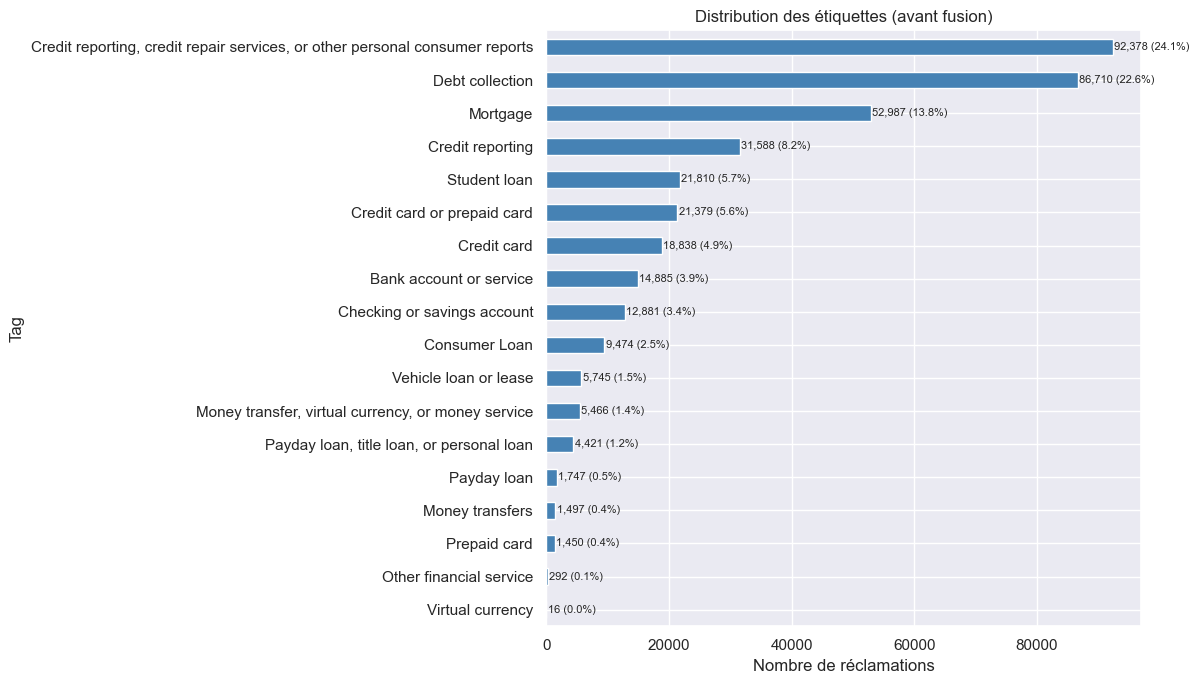

In [9]:
fig, ax = plt.subplots(figsize=(12, 7))
label_counts_raw.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Distribution des étiquettes (avant fusion)')
ax.set_xlabel('Nombre de réclamations')
for i, v in enumerate(label_counts_raw.sort_values()):
    ax.text(v + 200, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=8)
plt.tight_layout()
plt.show()

Observations :
- Les 3 premières classes dominent largement : `Credit reporting` (24.1%), `Debt collection` (22.6%), `Mortgage` (13.8%)
- Elles soit représentent 60% du dataset
- `Virtual currency` et `Other financial service` sont très minoritaires, le modèle aura peu d'exemples pour apprendre ces classes

In [10]:
# fusion cohérence
fusion_map = {
    'Credit reporting'  : 'Credit reporting, credit repair services, or other personal consumer reports',
    'Payday loan'       : 'Payday loan, title loan, or personal loan',
    'Money transfers'   : 'Money transfer, virtual currency, or money service',
    'Prepaid card'      : 'Credit card or prepaid card',
    'Virtual currency'  : 'Money transfer, virtual currency, or money service',
}
df[LABEL_COL] = df[LABEL_COL].replace(fusion_map)

label_counts = df[LABEL_COL].value_counts()
print(f'Nombre de classes après fusion : {len(label_counts)}')
print(label_counts)

Nombre de classes après fusion : 13
Tag
Credit reporting, credit repair services, or other personal consumer reports    123966
Debt collection                                                                  86710
Mortgage                                                                         52987
Credit card or prepaid card                                                      22829
Student loan                                                                     21810
Credit card                                                                      18838
Bank account or service                                                          14885
Checking or savings account                                                      12881
Consumer Loan                                                                     9474
Money transfer, virtual currency, or money service                                6979
Payday loan, title loan, or personal loan                                         6168
Veh

Observations :
- Après fusion, `Credit reporting` passe de 92 378 à 123 966 entrées, et devient encore plus dominante
- 13 classes finales cohérentes sont prêtes pour la modélisation

In [11]:
max_ratio = label_counts.max() / label_counts.min()
print(f'Ratio max/min entre classes : {max_ratio:.1f}x')
if max_ratio > 10:
    print('⚠️  Déséquilibre à prendre en compte dans le choix des métriques')

Ratio max/min entre classes : 424.5x
⚠️  Déséquilibre à prendre en compte dans le choix des métriques


Observations :
- Ratio de **424.5x** entre la classe la plus fréquente (`Credit reporting` : 123 966) et la plus rare (`Other financial service` : 292)
- Un ratio > 10x est considéré comme un fort déséquilibre l'accuracy serait trompeuse 
- Conséquence directe : on retient le F1 comme métrique principale

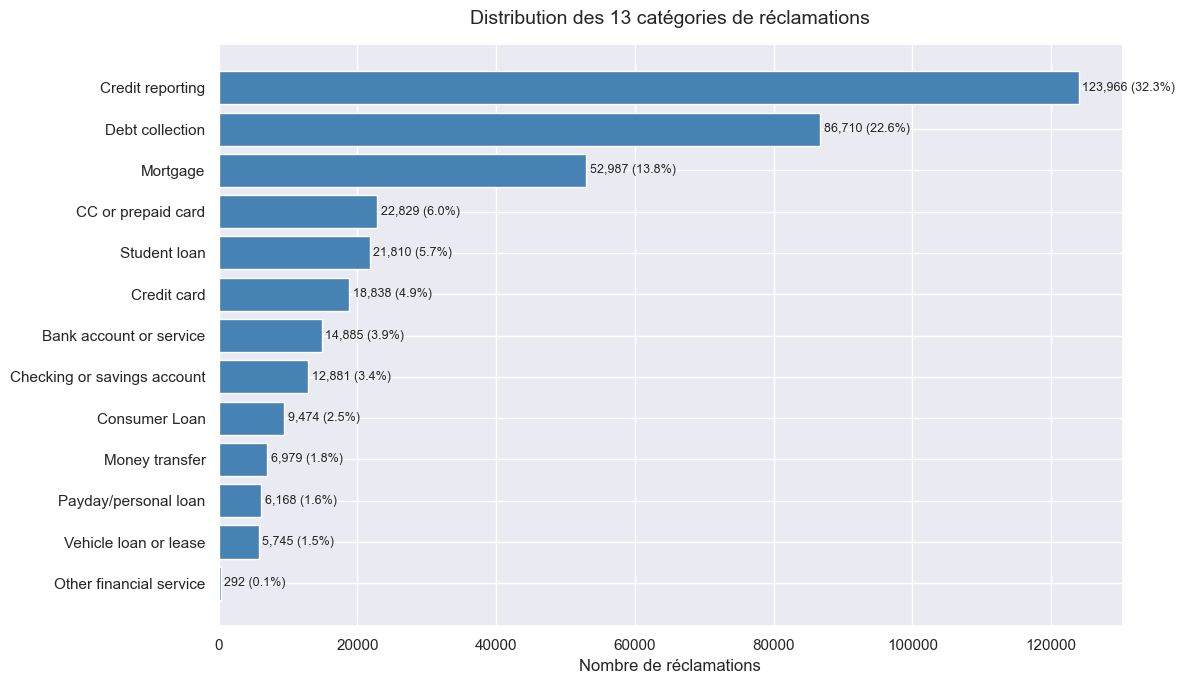

Graphique sauvegardé ✓


In [12]:
import matplotlib.pyplot as plt

label_counts_final = df[LABEL_COL].value_counts().sort_values()

# Labels courts
short_names = {
    'Credit reporting, credit repair services, or other personal consumer reports': 'Credit reporting',
    'Credit card or prepaid card': 'CC or prepaid card',
    'Payday loan, title loan, or personal loan': 'Payday/personal loan',
    'Money transfer, virtual currency, or money service': 'Money transfer',
}
labels_display = [short_names.get(l, l) for l in label_counts_final.index]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(labels_display, label_counts_final.values, color='steelblue')

for bar, val in zip(bars, label_counts_final.values):
    ax.text(val + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=9)

ax.set_title('Distribution des 13 catégories de réclamations', fontsize=14, pad=15)
ax.set_xlabel('Nombre de réclamations')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../data/distribution_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé ✓')

#### Points clés 
- Le dataset contient **13 classes** après fusion des doublons
- Les 3 premières classes représentent 60% des réclamations
- Fort déséquilibre : ratio **424.5x** entre la classe majoritaire et minoritaire
- Ce déséquilibre justifie le choix du F1 comme métrique principale plutôt que l'accuracy

<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.5 - Analyse du texte</h3>

Pourquoi analyser le texte ?
Pour comprendre le "volume" d'information disponible dans chaque réclamation. Cela permet d'anticiper la complexité du problème pour les modèles : plus le texte est long, plus il contient de signal pour la classification.

In [13]:
df['text_length'] = df[TEXT_COL].astype(str).apply(len)
df['word_count']  = df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

print('➡️ Longueur des textes (nbr caractères)')
print(df['text_length'].describe())
print('\n➡️ Nombre de mots')
print(df['word_count'].describe())
print(f'\nLongueur moyenne : {df["word_count"].mean():.0f} mots | Médiane : {df["word_count"].median():.0f} mots')

➡️ Longueur des textes (nbr caractères)
count    383564.000000
mean       1082.011278
std        1173.511078
min           5.000000
25%         393.000000
50%         744.000000
75%        1363.000000
max       31735.000000
Name: text_length, dtype: float64

➡️ Nombre de mots
count    383564.000000
mean        196.822382
std         211.063970
min           1.000000
25%          71.000000
50%         136.000000
75%         249.000000
max        6314.000000
Name: word_count, dtype: float64

Longueur moyenne : 197 mots | Médiane : 136 mots


Observations :
- Longueur moyenne de 197 mots et médiane de 136 mots
- Grande variabilité : de 1 mot minimum à 6 314 mots maximum

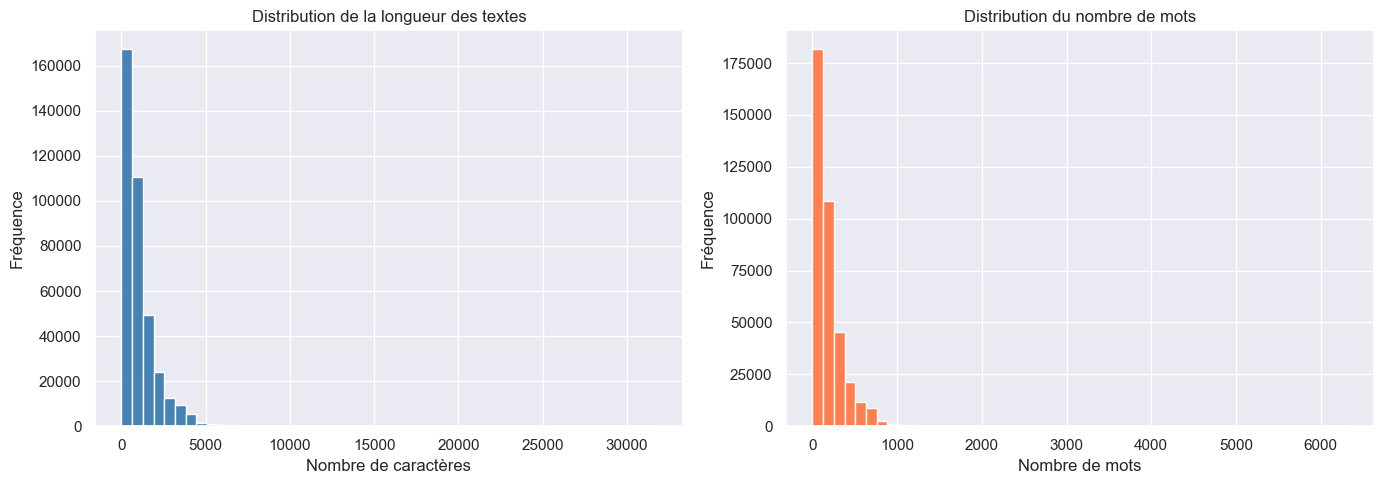

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution de la longueur des textes')
axes[0].set_xlabel('Nombre de caractères')
axes[0].set_ylabel('Fréquence')

axes[1].hist(df['word_count'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution du nombre de mots')
axes[1].set_xlabel('Nombre de mots')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

Observations :
- La majorité des réclamations se concentre entre 0 et 500 mots
- Ces textes extrêmement longs pourraient poser problème aux LLMs qui ont une limite de tokens en entrée

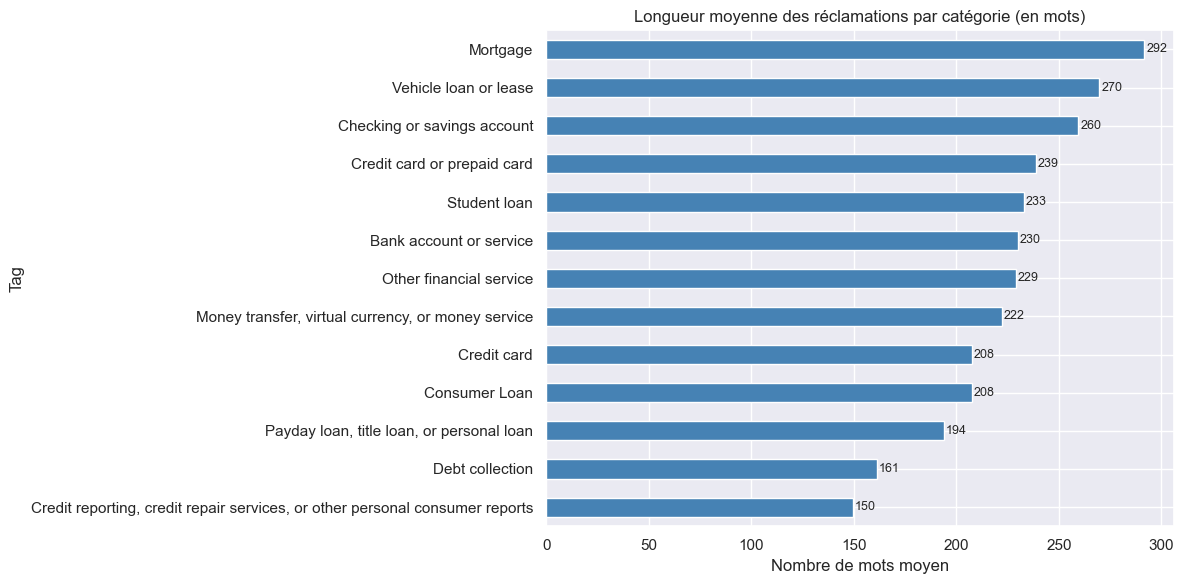

In [15]:
word_count_by_label = df.groupby(LABEL_COL)['word_count'].mean().sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
word_count_by_label.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Longueur moyenne des réclamations par catégorie (en mots)')
ax.set_xlabel('Nombre de mots moyen')
for i, v in enumerate(word_count_by_label):
    ax.text(v + 1, i, f'{v:.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Observations :
- `Mortgage` 292 mots et `Vehicle loan` 270 mots ont les textes les plus longs
- `Credit reporting` 150 mots a les textes les plus courts malgré sa forte fréquence

#### Points clés
- Réclamations en moyenne courtes mais avec une forte variabilité
- Distribution asymétrique : quelques textes très longs à surveiller pour les LLMs
- La longueur varie selon la catégorie `Mortgage` presque 2x plus long que `Credit reporting`

<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.6 - Préparation à la modélisation</h3>

On finalise ici la préparation des données avant la modélisation :
- Découpage du dataset en train/test
- Définition de la fonction d'évaluation et des métriques retenues
- Récapitulatif chiffré du dataset

In [16]:
X = df[TEXT_COL].astype(str)
y = df[LABEL_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

print(f'Train : {X_train.shape[0]} exemples ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Test  : {X_test.shape[0]} exemples ({X_test.shape[0]/len(df)*100:.1f}%)')
print(f'\nRépartition classes dans y_test :')
print(y_test.value_counts())

Train : 306851 exemples (80.0%)
Test  : 76713 exemples (20.0%)

Répartition classes dans y_test :
Tag
Credit reporting, credit repair services, or other personal consumer reports    24793
Debt collection                                                                 17342
Mortgage                                                                        10597
Credit card or prepaid card                                                      4566
Student loan                                                                     4362
Credit card                                                                      3768
Bank account or service                                                          2977
Checking or savings account                                                      2576
Consumer Loan                                                                    1895
Money transfer, virtual currency, or money service                               1396
Payday loan, title loan, or personal l

Observations :
- Split **80/20** : 306 851 exemples en train, 76 713 en test
- La répartition des classes est préservée grâce à `stratify=y`
- `Other financial service` n'a que 58 exemples en test (à surveiller) 
- `random_state=42` garantit que le même split sera obtenu à chaque exécution du notebook.

In [17]:
def evaluate_model(y_true, y_pred, model_name='Modèle', inference_time_s=None):
    """
    Évalue un modèle de classification avec les métriques retenues pour ZenAssist.
    
    Métriques :
    - F1 macro : adapté aux classes déséquilibrées, donne le même poids à chaque classe
    - Accuracy  : proportion globale de bonnes prédictions
    - Temps de réponse : expérience produit (latence pour les utilisateurs)
    """
    print(f'\n{'='*50}')
    print(f'  Évaluation : {model_name}')
    print(f'{'='*50}')
    
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    
    print(f'Accuracy  : {acc:.4f}')
    print(f'F1 macro  : {f1:.4f}')
    
    if inference_time_s is not None:
        n = len(y_true)
        ms_per_sample = (inference_time_s / n) * 1000
        print(f'Temps total  : {inference_time_s:.2f}s pour {n} exemples')
        print(f'Latence moy. : {ms_per_sample:.2f} ms/réclamation')
    
    print('\nRapport détaillé :')
    print(classification_report(y_true, y_pred))
    
    return {'accuracy': acc, 'f1_macro': f1, 'inference_time_s': inference_time_s}

print('✅ Fonction evaluate_model() définie')

✅ Fonction evaluate_model() définie


Métriques retenues :
- **F1 macro** : donne le même poids à chaque classe quelle que soit sa fréquence. Métrique principale, robuste au déséquilibre
- **Accuracy** : facile à communiquer au client mais trompeuse à cause du déséquilibre
- **Temps de réponse** : essentiel pour l'expérience produit

In [18]:
print('Résumé :')
print(f'Taille totale         : {len(df):,} réclamations')
print(f'Nombre de classes     : {df[LABEL_COL].nunique()}')
print(f'Doublons supprimés    : {n_dup}')
print(f'Longueur moy. (mots)  : {df["word_count"].mean():.0f}')
print(f'Ratio déséquilibre    : {max_ratio:.1f}x')
print(f'Split train/test      : {len(X_train):,} vs {len(X_test):,}')

Résumé :
Taille totale         : 383,564 réclamations
Nombre de classes     : 13
Doublons supprimés    : 0
Longueur moy. (mots)  : 197
Ratio déséquilibre    : 424.5x
Split train/test      : 306,851 vs 76,713


### Bilan de l'étape 1
L'analyse exploratoire nous a permis de prendre en main le dataset ZenAssist et de préparer les données pour la modélisation.

- Le dataset contient 383 564 réclamations exploitables
- Réclamations réparties en 13 classes 
- Fort déséquilibre entre les classes 424.5
- Choix du **F1 macro** comme métrique principale

Les données sont propres, le split train/test est prêt. On peut passer 
à la comparaison LLM vs Machine Learning.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">ÉTAPE 2 : Évaluation de l'approche LLM</h2>
</div>

### Objectifs de cette étape

Évaluer la capacité d'un LLM à classer automatiquement les réclamations sans entraînement préalable.

Phases de cette étape :
- Préparation de l'environnement
- Prompt V1 (zero-shot)
- Prompt V2 (few-shot)
- Prompt V3
- Évaluation finale
- Bilan LLM

<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Préparation de l'environnement</h3>

Chargement de la clé API Mistral et initialisation du client.
La clé est stockée dans un fichier `.env.local` pour ne jamais l'exposer 
dans le code source.

In [19]:
from dotenv import load_dotenv
import os
from mistralai.client import Mistral

load_dotenv('../.env.local')
MISTRAL_API_KEY = os.getenv('MISTRAL_API_KEY')
client = Mistral(api_key=MISTRAL_API_KEY)

MISTRAL_MODEL = 'mistral-small-latest'
print('Client Mistral initialisé ✅' if MISTRAL_API_KEY else '⚠️ Clé API non trouvée')
print(f'Modèle : {MISTRAL_MODEL}')

Client Mistral initialisé ✅
Modèle : mistral-small-latest


In [20]:
# Test de connexion avec une réclamation fictive
test_response = client.chat.complete(
    model=MISTRAL_MODEL,
    temperature=0,
    messages=[{"role": "user", "content": "Réponds juste 'OK' pour confirmer la connexion."}]
)
print(f'Connexion API : {test_response.choices[0].message.content}')

Connexion API : OK


<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Prompt V1 (zero-shot)</h3>

Le zero-shot consiste à demander directement au LLM de classifier une réclamation en lui donnant uniquement la liste des catégories possibles, sans aucun exemple.
C'est le point de départ naturel : on mesure ce que le modèle sait faire "seul".

In [21]:
LABELS = df[LABEL_COL].unique().tolist()

def predict_zero_shot(text):
    labels_str = '\n'.join(f'- {label}' for label in LABELS)
    prompt = f"""Tu es un assistant qui classe des réclamations de support client.
Classe la réclamation suivante dans exactement une des catégories ci-dessous.
Réponds UNIQUEMENT avec le nom exact de la catégorie, sans explication.

Catégories :
{labels_str}

Réclamation : {text}

Catégorie :"""

    response = client.chat.complete(
        model=MISTRAL_MODEL,
        temperature=0,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content.strip()

print('Fonction predict_zero_shot() définie')
print(f'Nombre de catégories : {len(LABELS)}')

Fonction predict_zero_shot() définie
Nombre de catégories : 13


In [23]:
sample_train = X_train.sample(20, random_state=42)
y_sample = y_train[sample_train.index]

predictions_v1 = []
for i, (idx, text) in enumerate(sample_train.items()):
    pred = predict_zero_shot(text)
    predictions_v1.append(pred)
    print(f'[{i+1:02d}/20] Vrai : {y_sample[idx][:40]:<40} | Prédit : {pred[:40]}')

correct = sum(1 for v, p in zip(y_sample.values, predictions_v1) if v == p)
print(f'\nRésultat : {correct}/20 correct ({correct/20:.0%})')

[01/20] Vrai : Debt collection                          | Prédit : Debt collection
[02/20] Vrai : Credit reporting, credit repair services | Prédit : Credit reporting, credit repair services
[03/20] Vrai : Credit reporting, credit repair services | Prédit : Credit reporting, credit repair services
[04/20] Vrai : Credit card or prepaid card              | Prédit : Credit card
[05/20] Vrai : Credit reporting, credit repair services | Prédit : Credit reporting, credit repair services
[06/20] Vrai : Debt collection                          | Prédit : Debt collection
[07/20] Vrai : Credit card                              | Prédit : Credit card
[08/20] Vrai : Credit reporting, credit repair services | Prédit : Credit reporting, credit repair services
[09/20] Vrai : Payday loan, title loan, or personal loa | Prédit : Debt collection
[10/20] Vrai : Credit reporting, credit repair services | Prédit : Credit reporting, credit repair services
[11/20] Vrai : Credit card                           

Observations :
- 70% de bonnes prédictions
- Les classes comme `Debt collection`, `Credit reporting` (sauf 1) sont bien identifiées
- Le modèle confond `Credit card or prepaid card` avec `Credit card`

In [ ]:
import pandas as pd

results_v1 = pd.DataFrame({
    'texte'   : sample_train.values,
    'vrai'    : y_sample.values,
    'prédit'  : predictions_v1,
})
results_v1['correct'] = results_v1['vrai'] == results_v1['prédit']

print(f'Accuracy sur 20 exemples : {results_v1["correct"].mean():.0%}')
print(f'\n--- Erreurs ---')
erreurs = results_v1[~results_v1['correct']]
for _, row in erreurs.iterrows():
    print(f'Vrai    : {row["vrai"]}')
    print(f'Prédit  : {row["prédit"]}')
    print(f'Texte   : {row["texte"][:100]}...')
    print()

Accuracy sur 20 exemples : 70%

--- Erreurs ---
Vrai    : Credit card or prepaid card
Prédit  : Credit card
Texte   : I have been an American Express customer for more than 5 years, frequently using their cards and ama...

Vrai    : Payday loan, title loan, or personal loan
Prédit  : Debt collection
Texte   : My current loan with XXXX is being managed by a debt management company, XXXX XXXX XXXX. The company...

Vrai    : Credit reporting, credit repair services, or other personal consumer reports
Prédit  : Credit card or prepaid card
Texte   : Back in XXXX, I had a XXXX XXXX XXXX XXXX ( Now Synchrony, JCPenny Card ). They kept charging me fee...

Vrai    : Credit card or prepaid card
Prédit  : Credit card
Texte   : I have a Chase Credit Card where I make a minimum payment to since the credit card was opened in XXX...

Vrai    : Credit card or prepaid card
Prédit  : Credit card
Texte   : I am an American Express Corporate Cardholder and had a fee for a balance that was overdue. This fe

‼️ Analyse des erreurs :
- 4/6 erreurs : confusion `Credit card` vs `Credit card or prepaid card` car le modèle utilise le libellé court plus naturel
- 1/6 : confusion `Payday loan` vs `Debt collection`, causé par l'ambiguïté quand le texte mentionne à la fois une dette et un prêt
- 1/6 : confusion `Credit reporting` vs `Credit card or prepaid card`, ici le modèle se focalise sur le produit mentionné plutôt que le sujet de la réclamation

➡️ Axes d'amélioration pour le V2 :
- Passer en few-shot avec des exemples sur les classes ambiguës
- Insister sur le respect du libellé exact des catégories

<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Prompt V2 (few-shot)</h3>

Le few-shot consiste à donner au modèle quelques exemples de classifications 
correctes avant de lui soumettre une nouvelle réclamation.

Améliorations apportées par rapport au V1 :
- Ajout d'exemples sur les classes ambiguës
- Appuie sur le respect du libellé exact des catégories
- Instruction explicite pour se concentrer sur le sujet de la réclamation 
plutôt que sur les produits

In [ ]:
# Exemples ciblés sur les classes ambiguës identifiées en V1
FEW_SHOT_EXAMPLES = [
    {
        "text": "I have a Chase Credit Card where I make a minimum payment each month.",
        "label": "Credit card or prepaid card"
    },
    {
        "text": "My credit report shows an incorrect account from a card I never opened.",
        "label": "Credit reporting, credit repair services, or other personal consumer reports"
    },
    {
        "text": "I took out a personal loan and the company is now sending it to collections.",
        "label": "Payday loan, title loan, or personal loan"
    },
    {
        "text": "A debt collector keeps calling me about a debt I already paid.",
        "label": "Debt collection"
    },
]

def predict_few_shot(text):
    labels_str = '\n'.join(f'- {label}' for label in LABELS)
    
    examples_str = '\n'.join(
        f'Réclamation : {ex["text"]}\nCatégorie : {ex["label"]}\n'
        for ex in FEW_SHOT_EXAMPLES
    )
    
    prompt = f"""Tu es un assistant qui classe des réclamations de support client financier.
Classe la réclamation dans exactement une des catégories listées.
Réponds UNIQUEMENT avec le nom exact de la catégorie, sans explication.
Attention : respecte le libellé exact, par exemple "Credit card or prepaid card" 
et non "Credit card" seul.
Concentre-toi sur le sujet principal de la réclamation, pas sur les produits mentionnés.

Catégories :
{labels_str}

Voici des exemples :
{examples_str}
Réclamation : {text}
Catégorie :"""

    response = client.chat.complete(
        model=MISTRAL_MODEL,
        temperature=0,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content.strip()

print('Fonction predict_few_shot() définie ✅')

Fonction predict_few_shot() définie ✅


In [ ]:
predictions_v2 = []
for i, (idx, text) in enumerate(sample_train.items()):
    pred = predict_few_shot(text)
    predictions_v2.append(pred)
    print(f'[{i+1:02d}/20] Vrai : {y_sample[idx][:40]:<40} | Prédit : {pred[:40]}')
correct = sum(1 for v, p in zip(y_sample.values, predictions_v2) if v == p)
print(f'\nRésultat : {correct}/20 correct ({correct/20:.0%})')

[01/20] Vrai : Debt collection                          | Prédit : Debt collection
[02/20] Vrai : Credit reporting, credit repair services | Prédit : Credit reporting, credit repair services
[03/20] Vrai : Credit reporting, credit repair services | Prédit : Credit reporting, credit repair services
[04/20] Vrai : Credit card or prepaid card              | Prédit : Credit card or prepaid card
[05/20] Vrai : Credit reporting, credit repair services | Prédit : Credit reporting, credit repair services
[06/20] Vrai : Debt collection                          | Prédit : Student loan
[07/20] Vrai : Credit card                              | Prédit : Credit card or prepaid card
[08/20] Vrai : Credit reporting, credit repair services | Prédit : Credit reporting, credit repair services
[09/20] Vrai : Payday loan, title loan, or personal loa | Prédit : Mortgage
[10/20] Vrai : Credit reporting, credit repair services | Prédit : Credit reporting, credit repair services
[11/20] Vrai : Credit card     

Observations :
- Amélioration de +10 points vs V1, passant à 80% de réussite
- La confusion `Credit card or prepaid card` et `Credit card` est corrigée
- De nouvelles erreurs sont présentes : sur-correction sur `Credit card` et confusion entre types de prêts

In [ ]:
results_v2 = pd.DataFrame({
    'texte'  : sample_train.values,
    'vrai'   : y_sample.values,
    'prédit' : predictions_v2,
})
results_v2['correct'] = results_v2['vrai'] == results_v2['prédit']

acc_v1 = results_v1['correct'].mean()
acc_v2 = results_v2['correct'].mean()

print(f'Accuracy V1 (zero-shot) : {acc_v1:.0%}')
print(f'Accuracy V2 (few-shot)  : {acc_v2:.0%}')
print(f'Amélioration            : +{(acc_v2 - acc_v1)*100:.0f} points')

print(f'\n--- Erreurs restantes V2 ---')
erreurs_v2 = results_v2[~results_v2['correct']]
if len(erreurs_v2) == 0:
    print('Aucune erreur ✓')
else:
    for _, row in erreurs_v2.iterrows():
        print(f'Vrai   : {row["vrai"]}')
        print(f'Prédit : {row["prédit"]}')
        print(f'Texte  : {row["texte"][:100]}...')
        print()

Accuracy V1 (zero-shot) : 70%
Accuracy V2 (few-shot)  : 80%
Amélioration            : +10 points

--- Erreurs restantes V2 ---
Vrai   : Debt collection
Prédit : Student loan
Texte  : The collection agency XXXX XXXX XXXX, is harassing me, and refuses to work with me in order to stop ...

Vrai   : Credit card
Prédit : Credit card or prepaid card
Texte  : My wife and I have several credit cards that we have charges on that are fraudulent. We were gullibl...

Vrai   : Payday loan, title loan, or personal loan
Prédit : Mortgage
Texte  : My current loan with XXXX is being managed by a debt management company, XXXX XXXX XXXX. The company...

Vrai   : Credit card
Prédit : Credit card or prepaid card
Texte  : i paid XXXX companies on my bb t card that took my money and rendered no service.i called my bb t ca...



‼️ Analyse des erreurs V2 :
- 2/4 erreurs : confusion inverse `Credit card` en `Credit card or prepaid card` 
- 1/4 : `Payday loan` devient `Consumer Loan`, il y a une ambiguïté entre types de prêts
- 1/4 : `Debt collection` devient `Student loan` erreur probablement liée au bruit dans le texte

<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.4 - Prompt V3 (few-shot amélioré)</h3>

In [ ]:
# Exemples enrichis avec les cas problématiques identifiés en V2
FEW_SHOT_EXAMPLES_V3 = [
    {
        "text": "I have a Chase Credit Card where I make a minimum payment each month.",
        "label": "Credit card or prepaid card"
    },
    {
        "text": "I used my prepaid card to make a purchase and the merchant charged me twice.",
        "label": "Credit card or prepaid card"
    },
    {
        "text": "My credit report shows an incorrect account from a card I never opened.",
        "label": "Credit reporting, credit repair services, or other personal consumer reports"
    },
    {
        "text": "I took out a small short-term payday loan and the lender is charging excessive fees.",
        "label": "Payday loan, title loan, or personal loan"
    },
    {
        "text": "I have a personal installment loan with my bank and they changed the terms.",
        "label": "Consumer Loan"
    },
    {
        "text": "A debt collector keeps calling me about a debt I already paid.",
        "label": "Debt collection"
    },
]

SYSTEM_PROMPT = """Tu es un assistant spécialisé dans la classification de réclamations 
de support client financier.

Règles importantes :
- Réponds UNIQUEMENT avec le nom exact de la catégorie, sans explication
- "Credit card" désigne uniquement les anciennes réclamations sur carte bancaire classique
- "Credit card or prepaid card" désigne les réclamations sur carte de crédit OU carte prépayée
- "Payday loan, title loan, or personal loan" désigne les prêts à court terme ou à taux élevé
- "Consumer Loan" désigne les prêts personnels classiques auprès d'une banque
- Concentre-toi sur le sujet principal de la réclamation, pas sur les produits mentionnés en passant"""

def predict_v3(text):
    labels_str = '\n'.join(f'- {label}' for label in LABELS)
    
    examples_str = '\n'.join(
        f'Réclamation : {ex["text"]}\nCatégorie : {ex["label"]}\n'
        for ex in FEW_SHOT_EXAMPLES_V3
    )
    
    user_prompt = f"""Catégories disponibles :
{labels_str}

Exemples :
{examples_str}
Réclamation : {text}
Catégorie :"""

    response = client.chat.complete(
        model=MISTRAL_MODEL,
        temperature=0,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_prompt}
        ]
    )
    return response.choices[0].message.content.strip()

print('Fonction predict_v3() définie ✅')

Fonction predict_v3() définie ✅


In [ ]:
predictions_v3 = []
for i, (idx, text) in enumerate(sample_train.items()):
    pred = predict_v3(text)
    predictions_v3.append(pred)
    print(f'[{i+1:02d}/20] Vrai : {y_sample[idx][:40]:<40} | Prédit : {pred[:40]}')

correct = sum(1 for v, p in zip(y_sample.values, predictions_v3) if v == p)
print(f'\nRésultat : {correct}/20 correct ({correct/20:.0%})')

[01/20] Vrai : Debt collection                          | Prédit : Debt collection
[02/20] Vrai : Credit reporting, credit repair services | Prédit : Credit reporting, credit repair services
[03/20] Vrai : Credit reporting, credit repair services | Prédit : Credit reporting, credit repair services
[04/20] Vrai : Credit card or prepaid card              | Prédit : Credit card or prepaid card
[05/20] Vrai : Credit reporting, credit repair services | Prédit : Credit reporting, credit repair services
[06/20] Vrai : Debt collection                          | Prédit : Student loan
[07/20] Vrai : Credit card                              | Prédit : Credit card or prepaid card
[08/20] Vrai : Credit reporting, credit repair services | Prédit : Credit reporting, credit repair services
[09/20] Vrai : Payday loan, title loan, or personal loa | Prédit : Consumer Loan
[10/20] Vrai : Credit reporting, credit repair services | Prédit : Credit reporting, credit repair services
[11/20] Vrai : Credit card

Observations :
- 14/20 correct, les résultats sont moins bons que la V2
- Les mêmes erreurs persistent et de nouvelles apparaissent
- Le modèle oscille maintenant dans les deux sens sur `Credit card` vs `Credit card or prepaid card`

In [ ]:
results_v3 = pd.DataFrame({
    'texte'  : sample_train.values,
    'vrai'   : y_sample.values,
    'prédit' : predictions_v3,
})
results_v3['correct'] = results_v3['vrai'] == results_v3['prédit']

acc_v1 = results_v1['correct'].mean()
acc_v2 = results_v2['correct'].mean()
acc_v3 = results_v3['correct'].mean()

print(f'Accuracy V1 (zero-shot)        : {acc_v1:.0%}')
print(f'Accuracy V2 (few-shot)         : {acc_v2:.0%}')
print(f'Accuracy V3 (few-shot amélioré): {acc_v3:.0%}')
print(f'\nMeilleure version : V{"3" if acc_v3 >= acc_v2 else "2"}')

print(f'\n--- Erreurs restantes V3 ---')
erreurs_v3 = results_v3[~results_v3['correct']]
if len(erreurs_v3) == 0:
    print('Aucune erreur ✓')
else:
    for _, row in erreurs_v3.iterrows():
        print(f'Vrai   : {row["vrai"]}')
        print(f'Prédit : {row["prédit"]}')
        print(f'Texte  : {row["texte"][:100]}...')
        print()
        

Accuracy V1 (zero-shot)        : 70%
Accuracy V2 (few-shot)         : 80%
Accuracy V3 (few-shot amélioré): 70%

Meilleure version : V2

--- Erreurs restantes V3 ---
Vrai   : Debt collection
Prédit : Student loan
Texte  : The collection agency XXXX XXXX XXXX, is harassing me, and refuses to work with me in order to stop ...

Vrai   : Credit card
Prédit : Credit card or prepaid card
Texte  : My wife and I have several credit cards that we have charges on that are fraudulent. We were gullibl...

Vrai   : Payday loan, title loan, or personal loan
Prédit : Consumer Loan
Texte  : My current loan with XXXX is being managed by a debt management company, XXXX XXXX XXXX. The company...

Vrai   : Credit card
Prédit : Credit card or prepaid card
Texte  : i paid XXXX companies on my bb t card that took my money and rendered no service.i called my bb t ca...

Vrai   : Credit card or prepaid card
Prédit : Credit card
Texte  : I have a Chase Credit Card where I make a minimum payment to since the cred

Conclusion : 

Trop de règles et d'exemples perturbent le modèle.
La V2 reste la meilleure version pour l'évaluation finale.

<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.5 - Évaluation finale</h3>

On évalue le prompt V2, qui est la meilleure version, sur un échantillon de 1000 réclamations du dataset de test pour obtenir des métriques fiables et comparables avec l'approche ML.

In [ ]:
SAMPLE_SIZE = 1000

sample_test = X_test.sample(SAMPLE_SIZE, random_state=42)
y_sample_test = y_test[sample_test.index]

print(f'Échantillon de test : {SAMPLE_SIZE} réclamations')
print(f'\nRépartition des classes :')
print(y_sample_test.value_counts())

Échantillon de test : 1000 réclamations

Répartition des classes :
Tag
Credit reporting, credit repair services, or other personal consumer reports    322
Debt collection                                                                 229
Mortgage                                                                        128
Credit card or prepaid card                                                      78
Student loan                                                                     62
Credit card                                                                      43
Bank account or service                                                          35
Checking or savings account                                                      35
Consumer Loan                                                                    23
Money transfer, virtual currency, or money service                               17
Payday loan, title loan, or personal loan                                        16
Vehic

In [ ]:
import time

predictions_final = []
errors_count = 0
start_time = time.time()

for i, (idx, text) in enumerate(sample_test.items()):
    try:
        pred = predict_few_shot(text)
        predictions_final.append(pred)
    except Exception as e:
        # En cas de rate limit : attendre et réessayer une fois
        print(f'⚠️ Rate limit ligne {i}, attente 10s...')
        time.sleep(10)
        try:
            pred = predict_few_shot(text)
            predictions_final.append(pred)
        except Exception as e2:
            print(f'⚠️ Échec définitif ligne {i}')
            predictions_final.append('ERREUR')
            errors_count += 1

    # Pause entre chaque appel pour éviter le rate limit
    time.sleep(0.5)

    if (i + 1) % 100 == 0:
        elapsed = time.time() - start_time
        remaining = (elapsed / (i + 1)) * (SAMPLE_SIZE - i - 1)
        print(f'[{i+1}/{SAMPLE_SIZE}] — {elapsed:.0f}s écoulées, ~{remaining:.0f}s restantes')

total_time = time.time() - start_time
print(f'\n✅ Terminé en {total_time:.0f}s')
print(f'Erreurs API : {errors_count}')

⚠️ Rate limit ligne 68, attente 10s...
⚠️ Rate limit ligne 79, attente 10s...
⚠️ Rate limit ligne 98, attente 10s...
[100/1000] — 123s écoulées, ~1107s restantes
⚠️ Rate limit ligne 124, attente 10s...
⚠️ Rate limit ligne 149, attente 10s...
⚠️ Rate limit ligne 174, attente 10s...
[200/1000] — 245s écoulées, ~980s restantes
⚠️ Rate limit ligne 210, attente 10s...
⚠️ Rate limit ligne 241, attente 10s...
⚠️ Rate limit ligne 262, attente 10s...
⚠️ Rate limit ligne 288, attente 10s...
[300/1000] — 381s écoulées, ~889s restantes
⚠️ Rate limit ligne 319, attente 10s...
⚠️ Rate limit ligne 347, attente 10s...
⚠️ Rate limit ligne 373, attente 10s...
⚠️ Rate limit ligne 397, attente 10s...
[400/1000] — 515s écoulées, ~772s restantes
⚠️ Rate limit ligne 425, attente 10s...
⚠️ Rate limit ligne 445, attente 10s...
⚠️ Rate limit ligne 473, attente 10s...
[500/1000] — 638s écoulées, ~638s restantes
⚠️ Rate limit ligne 502, attente 10s...
⚠️ Rate limit ligne 532, attente 10s...
⚠️ Rate limit ligne 55

In [ ]:
results_final = evaluate_model(
    y_true=y_sample_test.values,
    y_pred=predictions_final,
    model_name='LLM Mistral V2 (few-shot)',
    inference_time_s=total_time
)


  Évaluation : LLM Mistral V2 (few-shot)
Accuracy  : 0.6980
F1 macro  : 0.4515
Temps total  : 1296.12s pour 1000 exemples
Latence moy. : 1296.12 ms/réclamation

Rapport détaillé :
                                                                              precision    recall  f1-score   support

                                                     Bank account or service       0.27      0.83      0.40        35
                                                 Checking or savings account       0.00      0.00      0.00        35
                                                               Consumer Loan       0.10      0.04      0.06        23
                                                                 Credit card       0.00      0.00      0.00        43
                                                 Credit card or prepaid card       0.55      0.58      0.56        78
Credit reporting, credit repair services, or other personal consumer reports       0.78      0.89      0.83   

In [ ]:
# Sauvegarde pour comparaison future avec ML
df_results_llm = pd.DataFrame({
    'texte'  : sample_test.values,
    'vrai'   : y_sample_test.values,
    'prédit' : predictions_final,
})
df_results_llm['correct'] = df_results_llm['vrai'] == df_results_llm['prédit']
df_results_llm.to_csv('../data/results_llm.csv', index=False)

print('Résultats sauvegardés dans results_llm.csv')
print(f'\nRésumé :')
print(f'  Accuracy  : {results_final["accuracy"]:.2%}')
print(f'  F1 macro  : {results_final["f1_macro"]:.2%}')
print(f'  Temps total : {results_final["inference_time_s"]:.0f}s')
print(f'  Latence moy : {results_final["inference_time_s"]/SAMPLE_SIZE*1000:.0f} ms/réclamation')

Résultats sauvegardés dans results_llm.csv

Résumé :
  Accuracy  : 69.80%
  F1 macro  : 45.15%
  Temps total : 1296s
  Latence moy : 1296 ms/réclamation


Résultats LLM Mistral V2 (few-shot) sur 1000 exemples :

Accuracy : 69.8%
F1 macro : 45.15%
Latence moyenne : 1 296 ms/réclamation
Temps total : 1 296s pour 1 000 exemples

Analyse par classe :
- ✅ Bonnes performances : `Mortgage` (F1=0.90), `Credit reporting` (0.83), `Student loan` (0.83)
- ⚠️ Performances moyennes : `Debt collection` (0.71), `Credit card or prepaid card` (0.56)
- ❌ Échecs : `Checking or savings account` (0.00), `Credit card` (0.00), `Consumer Loan` (0.06), `Other financial service` (0.00)


#### Points clés
- **F1 macro : 45.15%** : métrique principale, pénalisée par les classes minoritaires
- **Accuracy : 69.8%** : trompeuse car le modèle se concentre sur les grandes classes
- **Latence : ~1.3s/réclamation** : trop long, incompatible avec un routage temps réel
- Le LLM excelle sur les classes avec beaucoup de signal textuel distinctif (`Mortgage`, `Student loan`) mais échoue sur les classes ambiguës ou rares

<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.6 - Bilan LLM</h3>

In [ ]:
bilan_llm = pd.DataFrame({
    'Version'   : ['V1 (zero-shot)', 'V2 (few-shot)', 'V3 (few-shot amélioré)'],
    'Accuracy'  : ['70%', '80%', '70%'],
    'Échantillon': ['20 exemples', '20 exemples', '20 exemples']
})
print(bilan_llm.to_string(index=False))
print()
print('➡️ Résultats finaux (V2 sur 1000 exemples)')
print(f'Accuracy       : 69.8%')
print(f'F1 macro       : 45.15%')
print(f'Latence moy.   : 1 296 ms/réclamation')
print(f'Coût estimé    : < 1€ pour 1 000 réclamations')

               Version Accuracy Échantillon
        V1 (zero-shot)      70% 20 exemples
         V2 (few-shot)      80% 20 exemples
V3 (few-shot amélioré)      70% 20 exemples

➡️ Résultats finaux (V2 sur 1000 exemples)
Accuracy       : 69.8%
F1 macro       : 45.15%
Latence moy.   : 1 296 ms/réclamation
Coût estimé    : < 1€ pour 1 000 réclamations


**✅ Points forts du LLM :**
- Zéro entraînement : aucune donnée labellisée nécessaire
- Facile à adapter : modifier le prompt suffit pour changer de domaine ou ajouter une nouvelle catégorie
- Bonnes performances sur les classes distinctives : `Mortgage` (F1=0.90), `Credit reporting` (0.83), `Student loan` (0.83)

**❌ Points faibles du LLM :**
- F1 macro faible : seulement 45%, échoue sur les classes minoritaires ou ambiguës
- Latence trop longue : 1 296 ms/réclamation, incompatible avec un routage temps réel (objectif < 100ms)
- Coût variable : croît linéairement avec le volume, or, ZenAssist traite des millions de réclamations
- Instabilité du parsing : le modèle peut répondre hors format malgré les instructions

## Bilan étape 2

L'approche LLM atteint **70% d'accuracy** et **45% de F1 macro** sur 1 000 
réclamations avec le prompt V2.

Si elle ne nécessite aucun entraînement, elle souffre d'une latence trop 
longue et d'un F1 macro insuffisant sur les classes minoritaires pour envisager un déploiement en production.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">ÉTAPE 3 : Évaluation de l'approche Machine Learning</h2>
</div>

### Objectifs de cette étape

Comparer les performances d'algorithmes de classification traditionnels avec l'approche LLM de l'étape 2.

Phases de cette étape :
- Préparation de l'environnement
- Vectorisation TF-IDF
- Entraînement et comparaison des modèles
- Analyse du meilleur modèle
- Bilan ML

<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.1 - Préparation de l'environnement</h3>

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.pipeline import Pipeline
import time

print('Imports ML OK ✓')

Imports ML OK ✓


<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.2 - Vectorisation TF-IDF</h3>

In [ ]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True, 
    min_df=5, 
    strip_accents='unicode',
    analyzer='word'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Vocabulaire TF-IDF : {len(tfidf.vocabulary_):,} termes')
print(f'Shape X_train : {X_train_tfidf.shape}')
print(f'Shape X_test  : {X_test_tfidf.shape}')

Vocabulaire TF-IDF : 50,000 termes
Shape X_train : (306851, 50000)
Shape X_test  : (76713, 50000)


In [ ]:
density = X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
print(f'Densité de la matrice : {density:.4%}')
print(f'Cellules non nulles   : {X_train_tfidf.nnz:,}')
print(f'Cellules totales      : {X_train_tfidf.shape[0] * X_train_tfidf.shape[1]:,}')

Densité de la matrice : 0.4045%
Cellules non nulles   : 62,062,338
Cellules totales      : 15,342,550,000


Observations :
- Densité de 0.4% donc 99.6% des cellules sont à zéro
- Seulement 62M de valeurs utiles sur 15 milliards de cellules totales
- En format dense, cette matrice pèserait 115 Go en RAM, trop lourd pour la stocker.
- Sklearn utilise automatiquement le format sparse (donc creux) qui ne stocke que les valeurs non nulles.

In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print('Classes encodées :')
for i, cls in enumerate(le.classes_):
    print(f'  {i:2d} : {cls}')

Classes encodées :
   0 : Bank account or service
   1 : Checking or savings account
   2 : Consumer Loan
   3 : Credit card
   4 : Credit card or prepaid card
   5 : Credit reporting, credit repair services, or other personal consumer reports
   6 : Debt collection
   7 : Money transfer, virtual currency, or money service
   8 : Mortgage
   9 : Other financial service
  10 : Payday loan, title loan, or personal loan
  11 : Student loan
  12 : Vehicle loan or lease


Observations :
- 13 classes encodées de 0 à 12
- `LabelEncoder` trie les classes par ordre alphabétique
- Ces encodages numériques sont nécessaires pour certains algorithmes comme LinearSVC et SGD qui n'acceptent pas les labels texte directement

#### Points clés
- Le texte est transformé en 306 851 × 50 000 features numériques
- Les bigrammes (`ngram_range=(1,2)`) permettent de capturer des expressions clés comme "credit card" ou "debt collection" en un seul token
- `sublinear_tf=True` évite qu'un mot répété 100 fois pèse 100x plus qu'un mot répété 10 fois

<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.3 - Entraînement et comparaison des modèles</h3>

On entraîne quatre algorithmes classiques de classification de texte et on compare leurs performances sur le même jeu de test.

On va utiliser le parametre `class_weight='balanced'` pour compenser le déséquilibre.

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'LinearSVC': LinearSVC(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'SGDClassifier': SGDClassifier(
        loss='modified_huber',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
}
print(f'{len(models)} modèles définis ✅')

4 modèles définis ✅


In [ ]:
results_ml = {}

for name, model in models.items():
    print(f'\n→ Entraînement : {name}...')
    
    # Entraînement
    start = time.time()
    model.fit(X_train_tfidf, y_train_enc)
    train_time = time.time() - start
    
    # Prédiction
    start = time.time()
    y_pred = model.predict(X_test_tfidf)
    inference_time = time.time() - start
    
    # Métriques
    acc = accuracy_score(y_test_enc, y_pred)
    f1  = f1_score(y_test_enc, y_pred, average='macro')
    latency_ms = (inference_time / len(y_test_enc)) * 1000
    
    results_ml[name] = {
        'accuracy'    : acc,
        'f1_macro'    : f1,
        'train_time_s': train_time,
        'latency_ms'  : latency_ms,
    }
    print(f'   Accuracy  : {acc:.4f}')
    print(f'   F1 macro  : {f1:.4f}')
    print(f'   Train     : {train_time:.1f}s')
    print(f'   Latence   : {latency_ms:.2f} ms/réclamation')


→ Entraînement : Logistic Regression...
   Accuracy  : 0.7941
   F1 macro  : 0.6528
   Train     : 133.2s
   Latence   : 0.00 ms/réclamation

→ Entraînement : LinearSVC...
   Accuracy  : 0.8086
   F1 macro  : 0.6384
   Train     : 148.2s
   Latence   : 0.00 ms/réclamation

→ Entraînement : SGDClassifier...
   Accuracy  : 0.8024
   F1 macro  : 0.6511
   Train     : 1.7s
   Latence   : 0.00 ms/réclamation

→ Entraînement : Random Forest...
   Accuracy  : 0.7896
   F1 macro  : 0.5750
   Train     : 321.1s
   Latence   : 0.01 ms/réclamation


Observations :
- Tous les modèles dépassent largement le LLM en F1 macro
- La latence est beaucoup moins importante que le LLM
- `SGDClassifier` se distingue : performances équivalentes à la Logistic Regression mais 78x plus rapide à l'entraînement (1.7s contre 133s)

In [ ]:
df_results = pd.DataFrame(results_ml).T
df_results = df_results.sort_values('f1_macro', ascending=False)
df_results['accuracy']  = df_results['accuracy'].apply(lambda x: f'{x:.2%}')
df_results['f1_macro']  = df_results['f1_macro'].apply(lambda x: f'{x:.2%}')
df_results['latency_ms'] = df_results['latency_ms'].apply(lambda x: f'{x:.3f} ms')
df_results['train_time_s'] = df_results['train_time_s'].apply(lambda x: f'{x:.1f}s')

print('Comparaison des modèles ML')
print(df_results.to_string())

Comparaison des modèles ML
                    accuracy f1_macro train_time_s latency_ms
Logistic Regression   79.41%   65.28%       133.2s   0.001 ms
SGDClassifier         80.24%   65.11%         1.7s   0.001 ms
LinearSVC             80.86%   63.84%       148.2s   0.001 ms
Random Forest         78.96%   57.50%       321.1s   0.007 ms


➡️ Classement final :

Logistic Regression est le modèle qui sera retenu car il a une meilleur F1 macro. Cependant le SGDClassifier est une alternative sérieuse si le temps d'entraînement devient une contrainte.

**Logistic Regression**
F1 macro : 65.28%
Accuracy : 79.41% 
Train : 133s
Latence : 0.001ms 

<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.4 - Analyse du meilleur modèle</h3>

On va approfondir l'analyse de la Logistic Regression.
L'objectif est de comprendre où le modèle se trompe et si ses performances 
sont fiables sur toutes les classes.

In [ ]:
best_model = models['Logistic Regression']
y_pred_best = best_model.predict(X_test_tfidf)

print('Rapport détaillé : Logistic Regression')
print(classification_report(
    y_test_enc, y_pred_best,
    target_names=le.classes_
))

Rapport détaillé : Logistic Regression
                                                                              precision    recall  f1-score   support

                                                     Bank account or service       0.61      0.64      0.63      2977
                                                 Checking or savings account       0.64      0.68      0.66      2576
                                                               Consumer Loan       0.41      0.54      0.47      1895
                                                                 Credit card       0.56      0.67      0.61      3768
                                                 Credit card or prepaid card       0.62      0.66      0.64      4566
Credit reporting, credit repair services, or other personal consumer reports       0.93      0.80      0.86     24793
                                                             Debt collection       0.86      0.82      0.84     17342
                

Observation :
- Excellentes performances : `Mortgage` (F1=0.92), `Student loan` (0.88), `Credit reporting` (0.86), `Debt collection` (0.84)
- Performances moyennes : `Money transfer` (0.77), `Checking` (0.66), `Credit card or prepaid card` (0.64)
- Classes faibles : `Other financial service` (0.21), `Consumer Loan` (0.47), `Vehicle loan` (0.50), `Payday loan` (0.51)

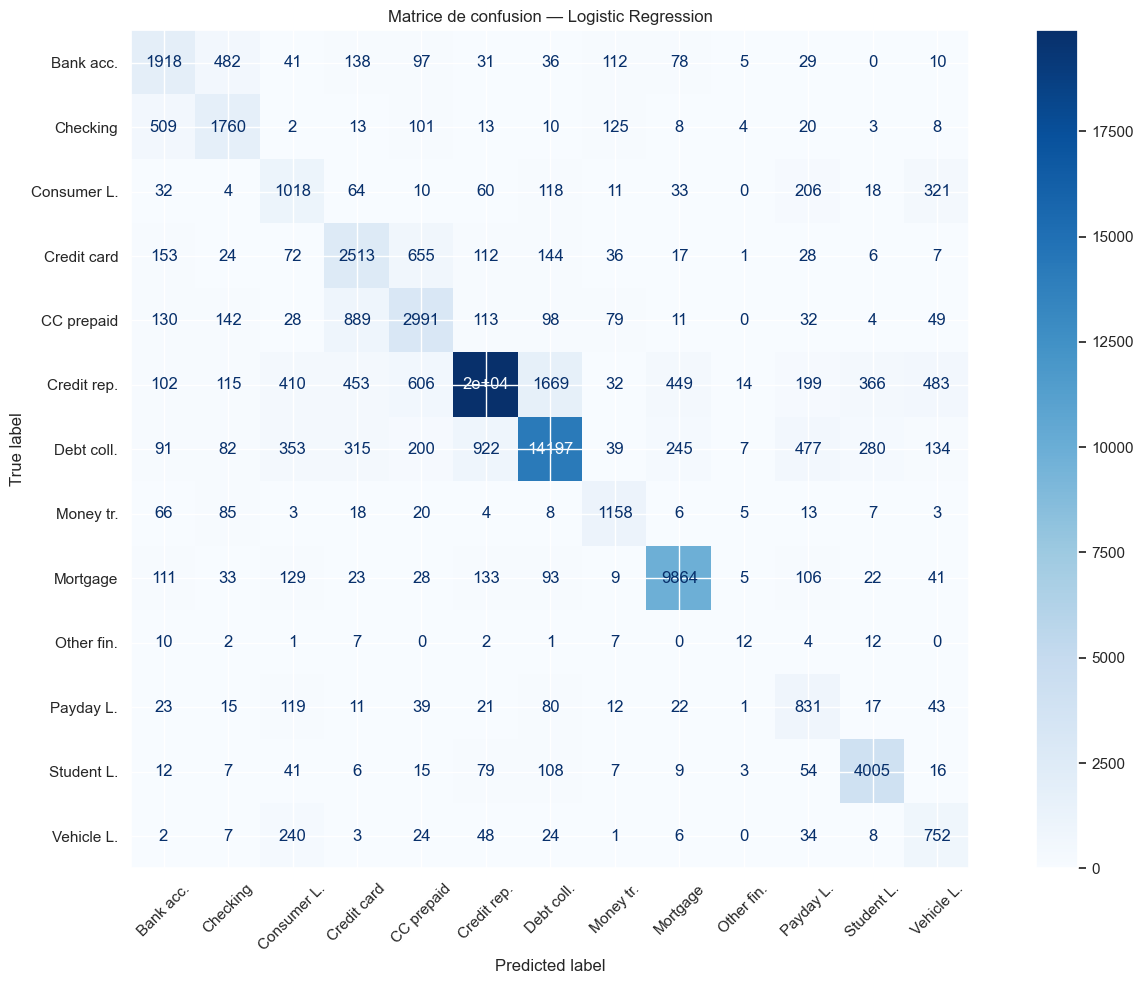

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Labels courts pour la lisibilité
short_labels = [
    'Bank acc.', 'Checking', 'Consumer L.',
    'Credit card', 'CC prepaid', 'Credit rep.',
    'Debt coll.', 'Money tr.', 'Mortgage',
    'Other fin.', 'Payday L.', 'Student L.', 'Vehicle L.'
]

cm = confusion_matrix(y_test_enc, y_pred_best)
fig, ax = plt.subplots(figsize=(14, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_labels)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
ax.set_title('Matrice de confusion — Logistic Regression')
plt.tight_layout()
plt.show()

**📊 Principales confusions identifiées :**
- `Bank account` et `Checking` classes sémantiquement très proches, difficiles à distinguer même pour un humain
- `Credit card` et `Credit card or prepaid card` même ambiguïté structurelle que dans l'approche LLM
- `Consumer Loan`, `Vehicle loan` et `Payday loan`, les types de prêts partagent un vocabulaire similaire
- `Credit reporting` absorbe de nombreuses erreurs des autres classes biais dû à sa forte représentation

In [ ]:
print('➡️ Comparaison finale LLM et ML\n')
print(f'{"Métrique":<25} {"LLM V2":>12} {"Logistic Reg.":>15}')
print('-' * 55)
print(f'{"Accuracy":<25} {"69.80%":>12} {"79.41%":>15}')
print(f'{"F1 macro":<25} {"45.15%":>12} {"65.28%":>15}')
print(f'{"Latence moy.":<25} {"1296 ms":>12} {"0.001 ms":>15}')
print(f'{"Entraînement requis":<25} {"Non":>12} {"Oui":>15}')
print(f'{"Coût à l\'échelle":<25} {"Variable":>12} {"Fixe":>15}')
print(f'{"Adaptable sans données":<25} {"Oui":>12} {"Non":>15}')

➡️ Comparaison finale LLM et ML

Métrique                        LLM V2   Logistic Reg.
-------------------------------------------------------
Accuracy                        69.80%          79.41%
F1 macro                        45.15%          65.28%
Latence moy.                   1296 ms        0.001 ms
Entraînement requis                Non             Oui
Coût à l'échelle              Variable            Fixe
Adaptable sans données             Oui             Non


#### Points clés
- F1 macro : passe de 45.15% pour le LLM à 65.28% avec Logistic Regression
- Latence : passe de 1 296ms à 0.001ms
- Les confusions restantes (`Credit card` vs `CC prepaid`, types de prêts) sont structurelles — présentes dans les deux approches
- `Other financial service` reste problématique : seulement 292 exemples dans le dataset (donc rare)

<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.5 - Bilan ML</h3>

In [ ]:
print('=== BILAN APPROCHE MACHINE LEARNING ===\n')
print(f'{"Modèle":<25} {"F1 macro":>10} {"Accuracy":>10} {"Train":>10} {"Latence":>12}')
print('-' * 70)
print(f'{"Logistic Regression":<25} {"65.28%":>10} {"79.41%":>10} {"133s":>10} {"0.001ms":>12}')
print(f'{"SGDClassifier":<25} {"65.11%":>10} {"80.24%":>10} {"1.7s":>10} {"0.001ms":>12}')
print(f'{"LinearSVC":<25} {"63.84%":>10} {"80.86%":>10} {"148s":>10} {"0.001ms":>12}')
print(f'{"Random Forest":<25} {"57.50%":>10} {"78.96%":>10} {"321s":>10} {"0.007ms":>12}')
print()
print('Modèle retenu : Logistic Regression (meilleur F1 macro)')

=== BILAN APPROCHE MACHINE LEARNING ===

Modèle                      F1 macro   Accuracy      Train      Latence
----------------------------------------------------------------------
Logistic Regression           65.28%     79.41%       133s      0.001ms
SGDClassifier                 65.11%     80.24%       1.7s      0.001ms
LinearSVC                     63.84%     80.86%       148s      0.001ms
Random Forest                 57.50%     78.96%       321s      0.007ms

Modèle retenu : Logistic Regression (meilleur F1 macro)


Observations :
- La Logistic Regression et le SGDClassifier sont quasi équivalents en F1. Le choix dépendra du contexte de déploiement.
- Le Random Forest est clairement inadapté c'ets le moins bon modèle
- Tous les modèles ML ont une latence inférieur à 0.01ms ils sont donc nettement plus rapide que le LLM ✅

## Bilan étape 3

L'approche ML avec TF-IDF et Logistic Regression atteint **65% de F1 macro** 
et **79% d'accuracy** avec une latence quasi nulle.

Elle surpasse clairement le LLM sur tous les critères quantitatifs et est 
parfaitement adaptée au déploiement en production chez ZenAssist.